# Almayra Edgina Rahma 2802460930

Link video penjelasan: https://youtu.be/RINJdgunmqw

# Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier, XGBRegressor
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data_D_(2).csv")
df.head()


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20c27,CUS_0xf64,June,NaN,32,478-73-8323,Doctor,56125.5,4875.125000,...,Standard,370.22,32.014182,28 Years and 10 Months,Yes,81.822857,182.06551022025016,High_spent_Medium_value_payments,473.62413320457887,Standard
1,1,0xc518,CUS_0x697f,March,Philh,39,367-66-5050,Entrepreneur,62148.0,NaN,...,Bad,2373.61,33.951720,16 Years and 6 Months,Yes,258.848861,195.3722153038279,High_spent_Small_value_payments,300.6789235920986,Poor
2,2,0x22663,CUS_0x7846,February,Paramadithak,45,282-14-9365,Accountant,88380.16,7471.013333,...,_,124.29,41.016763,NaN,Yes,129.723699,180.79874191787297,High_spent_Medium_value_payments,686.5788927990964,Standard
3,3,0x1ff7,CUS_0x3ef5,June,Robinsonl,32,259-09-9023,_______,7821.24,468.770000,...,Bad,2924.76,34.203026,10 Years and 2 Months,Yes,19.727923,39.93770264234067,Low_spent_Medium_value_payments,267.2113738653678,Standard
4,4,0x9a07,CUS_0x8fdf,June,Yeeo,18,312-56-4208,Scientist,107871.9,NaN,...,Standard,1005.83,27.237916,32 Years and 8 Months,No,227.241789,73.48570828760295,High_spent_Large_value_payments,820.9050026625811,Standard


# Preprocessing

In [3]:
df.shape

(25000, 29)

In [4]:
for col in df.columns:
    print(f'{col}= {df[col].isnull().mean()*100}')
    print("--------------------------------------")

Unnamed: 0= 0.0
--------------------------------------
ID= 0.0
--------------------------------------
Customer_ID= 0.0
--------------------------------------
Month= 0.0
--------------------------------------
Name= 10.116
--------------------------------------
Age= 0.0
--------------------------------------
SSN= 0.0
--------------------------------------
Occupation= 0.0
--------------------------------------
Annual_Income= 0.0
--------------------------------------
Monthly_Inhand_Salary= 15.308
--------------------------------------
Num_Bank_Accounts= 0.0
--------------------------------------
Num_Credit_Card= 0.0
--------------------------------------
Interest_Rate= 0.0
--------------------------------------
Num_of_Loan= 0.0
--------------------------------------
Type_of_Loan= 11.52
--------------------------------------
Delay_from_due_date= 0.0
--------------------------------------
Num_of_Delayed_Payment= 6.976
--------------------------------------
Changed_Credit_Limit= 0.0
--------

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22471 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21173 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [7]:
df.columns

Index(['Unnamed: 0', 'ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN',
       'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [8]:
df.drop(columns=['Unnamed: 0', 'ID', 'SSN','Customer_ID','Name'], inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  object 
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  object 
 4   Monthly_Inhand_Salary     21173 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  object 
 9   Type_of_Loan              22120 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23256 non-null  object 
 12  Changed_Credit_Limit      25000 non-null  object 
 13  Num_Credit_Inquiries      24503 non-null  float64
 14  Credit

In [10]:
num = ['Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
       'Delay_from_due_date','Num_Credit_Inquiries','Credit_Utilization_Ratio',
       'Total_EMI_per_month']

obj = ['Month','Age','Occupation', 'Annual_Income','Num_of_Loan',
       'Type_of_Loan','Num_of_Delayed_Payment',
       'Changed_Credit_Limit','Credit_Mix',
       'Outstanding_Debt','Credit_History_Age',
       'Payment_of_Min_Amount','Amount_invested_monthly',
       'Payment_Behaviour', 'Monthly_Balance']

y= df['Credit_Score']

In [11]:
df[obj].head()

,Month,Age,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,June,32,Doctor,56125.5,2,"Credit-Builder Loan, and Mortgage Loan",14,17.89,Standard,370.22,28 Years and 10 Months,Yes,182.06551022025016,High_spent_Medium_value_payments,473.62413320457887
1,March,39,Entrepreneur,62148.0,5,"Mortgage Loan, Personal Loan, Payday Loan, Per...",25,_,Bad,2373.61,16 Years and 6 Months,Yes,195.3722153038279,High_spent_Small_value_payments,300.6789235920986
2,February,45,Accountant,88380.16,3,"Student Loan, Home Equity Loan, and Credit-Bui...",19,8.7,_,124.29,NaN,Yes,180.79874191787297,High_spent_Medium_value_payments,686.5788927990964
3,June,32,_______,7821.24,6,"Mortgage Loan, Personal Loan, Home Equity Loan...",17,19.34,Bad,2924.76,10 Years and 2 Months,Yes,39.93770264234067,Low_spent_Medium_value_payments,267.2113738653678
4,June,18,Scientist,107871.9,3,"Student Loan, Mortgage Loan, and Credit-Builde...",20,11.27,Standard,1005.83,32 Years and 8 Months,No,73.48570828760295,High_spent_Large_value_payments,820.9050026625811


Beberapa data objek perlu diubah ke numerik
- Age
- Num of loan
- Annual Income
- Num_of_Delayed_Payment
- Changed_Credit_Limit
- Credit_History_Age
- Amount_invested_monthly
- Monthly_Balance

In [12]:
suscols = [
    'Age',
    'Annual_Income',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in suscols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Age ---
Age
27      708
31      702
44      701
28      701
26      695
       ... 
2369      1
1294      1
6674      1
1062      1
819       1
Name: count, Length: 548, dtype: int64

--- Annual_Income ---
Annual_Income
29020.78             8
9141.63              8
20867.67             7
26508.58             7
19114.12             7
                    ..
106928.84            1
40021.11             1
54346.35000000001    1
118636.88            1
120955.92            1
Name: count, Length: 12749, dtype: int64

--- Num_of_Loan ---
Num_of_Loan
3       3610
2       3590
4       3507
0       2633
1       2565
        ... 
1035       1
300        1
917        1
720        1
1039       1
Name: count, Length: 131, dtype: int64

--- Num_of_Delayed_Payment ---
Num_of_Delayed_Payment
17      1367
19      1319
16      1293
15      1277
10      1254
        ... 
468        1
1531       1
2508       1
4340       1
2801       1
Name: count, Length: 241, dtype: int64

--- Changed_Credit_Limit ---

In [13]:
for col in suscols:
    bad = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
    print(f"{col}: {bad.sum()} -> {bad.sum()/25000}% problematic values")

Age: 1230 -> 0.0492% problematic values
Annual_Income: 1697 -> 0.06788% problematic values
Num_of_Loan: 1164 -> 0.04656% problematic values
Num_of_Delayed_Payment: 687 -> 0.02748% problematic values
Changed_Credit_Limit: 523 -> 0.02092% problematic values
Outstanding_Debt: 267 -> 0.01068% problematic values
Amount_invested_monthly: 1092 -> 0.04368% problematic values
Monthly_Balance: 3 -> 0.00012% problematic values


In [14]:
for col in suscols:
    bad_mask = (
        pd.to_numeric(df[col], errors='coerce').isna()
        & df[col].notna()
    )

    print(f"\n===== {col} =====")
    print(df.loc[bad_mask, col].unique()[:20])  # first 20 unique bad values


===== Age =====
['52_' '28_' '24_' '23_' '27_' '20_' '44_' '38_' '36_' '19_' '26_' '30_'
 '32_' '34_' '21_' '55_' '31_' '42_' '49_' '16_']

===== Annual_Income =====
['59375.22_' '92807.49_' '43115.38_' '31029.87_' '43894.24_' '26520.9_'
 '17868.11_' '34946.42_' '25530.33_' '73062.6_' '17723.52_' '18248.5_'
 '63093.32_' '14433.725_' '26693.06_' '18399.84_' '37516.41_' '87786.15_'
 '14293.6_' '60040.5_']

===== Num_of_Loan =====
['9_' '4_' '2_' '6_' '3_' '1_' '0_' '5_' '7_' '8_' '1225_' '1132_' '1311_'
 '1129_' '527_' '1347_' '1219_' '378_' '630_']

===== Num_of_Delayed_Payment =====
['23_' '10_' '24_' '12_' '18_' '13_' '16_' '22_' '25_' '19_' '15_' '11_'
 '21_' '20_' '17_' '14_' '7_' '-1_' '8_' '6_']

===== Changed_Credit_Limit =====
['_']

===== Outstanding_Debt =====
['155.2_' '2598.21_' '4598.96_' '2256.77_' '4461.39_' '761.18_' '899.28_'
 '1248.05_' '2563.0_' '1326.06_' '923.5_' '1358.96_' '1328.93_' '2318.76_'
 '28.15_' '328.91_' '50.13_' '3271.84_' '1103.08_' '1457.54_']

===== 

In [15]:
for col in suscols:

    temp = df[col].astype(str)
    temp = temp.str.replace('_', '', regex=False)
    temp = temp.str.replace('nan', '', regex=False)

    try:
        pd.to_numeric(temp)
    except Exception as e:
        print(f"\nColumn: {col}")
        print("Error:", e)

        # Print very long values
        mask = temp.str.len() > 18
        print("\nSuspicious values:")
        print(temp[mask].unique())

        break




Column: Monthly_Balance
Error: Integer out of range. at position 6212

Suspicious values:
['-333333333333333333333333333']


In [16]:
df['Monthly_Balance'] = df['Monthly_Balance'].str.replace('__-333333333333333333333333333__', '', regex=False)

In [17]:
for col in suscols:

    df[col] = df[col].str.replace('_', '', regex=False)
    df[col] = df[col].str.replace('nan', '', regex=False)
    df[col]= df[col].apply(pd.to_numeric)


### Convert Credit history age ke angka

In [18]:
df['Credit_History_Age']

,Credit_History_Age
0,28 Years and 10 Months
1,16 Years and 6 Months
2,NaN
3,10 Years and 2 Months
4,32 Years and 8 Months
...,...
24995,33 Years and 3 Months
24996,17 Years and 7 Months
24997,31 Years and 9 Months
24998,13 Years and 11 Months


In [19]:
pattern = r'^\d+\s+Years?\s+and\s+\d+\s+Months?$'

invalid = df[
    df['Credit_History_Age'].notna() &
    ~df['Credit_History_Age'].astype(str).str.match(pattern)
]

print(f"Invalid rows: {len(invalid)}")
invalid[['Credit_History_Age']].head(20)

Invalid rows: 0


,Credit_History_Age


In [20]:
import numpy as np
import pandas as pd

# Extract years and months
temp = df['Credit_History_Age'].str.extract(
    r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?'
)

# Convert to numeric
years = pd.to_numeric(temp[0])
months = pd.to_numeric(temp[1])

# Total months
df['Credit_History_Age_Months'] = years * 12 + months

In [21]:
df = df.drop(columns=['Credit_History_Age'])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      25000 non-null  object 
 1   Age                        25000 non-null  int64  
 2   Occupation                 25000 non-null  object 
 3   Annual_Income              25000 non-null  float64
 4   Monthly_Inhand_Salary      21173 non-null  float64
 5   Num_Bank_Accounts          25000 non-null  int64  
 6   Num_Credit_Card            25000 non-null  int64  
 7   Interest_Rate              25000 non-null  int64  
 8   Num_of_Loan                25000 non-null  int64  
 9   Type_of_Loan               22120 non-null  object 
 10  Delay_from_due_date        25000 non-null  int64  
 11  Num_of_Delayed_Payment     23256 non-null  float64
 12  Changed_Credit_Limit       24477 non-null  float64
 13  Num_Credit_Inquiries       24503 non-null  flo

In [23]:
num=['Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Delay_from_due_date',
 'Num_Credit_Inquiries',
 'Credit_Utilization_Ratio',
 'Total_EMI_per_month',
 'Age',
 'Annual_Income',
 'Num_of_Loan',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Outstanding_Debt',
 'Amount_invested_monthly',
 'Monthly_Balance',
 'Credit_History_Age_Months']

## Target - Classification


In [24]:
y

,Credit_Score
0,Standard
1,Poor
2,Standard
3,Standard
4,Standard
...,...
24995,Standard
24996,Standard
24997,Standard
24998,Standard


In [25]:
df['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,13305
Poor,7231
Good,4464


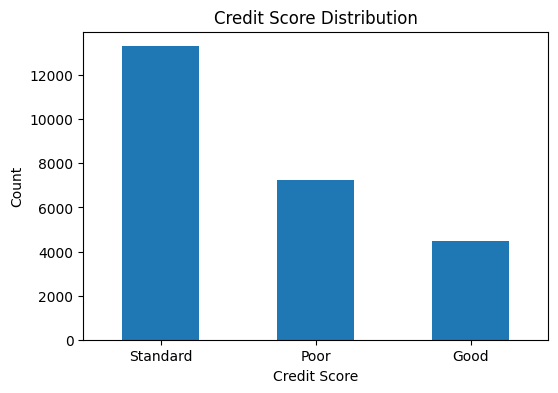

In [26]:
fig, ax = plt.subplots(figsize=(6,4))

df['Credit_Score'].value_counts().plot(kind='bar', ax=ax)

ax.set_title('Credit Score Distribution')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Count')
plt.xticks(rotation=0)

plt.show()

##Numeric

In [27]:
num

['Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Delay_from_due_date',
 'Num_Credit_Inquiries',
 'Credit_Utilization_Ratio',
 'Total_EMI_per_month',
 'Age',
 'Annual_Income',
 'Num_of_Loan',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Outstanding_Debt',
 'Amount_invested_monthly',
 'Monthly_Balance',
 'Credit_History_Age_Months']

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      25000 non-null  object 
 1   Age                        25000 non-null  int64  
 2   Occupation                 25000 non-null  object 
 3   Annual_Income              25000 non-null  float64
 4   Monthly_Inhand_Salary      21173 non-null  float64
 5   Num_Bank_Accounts          25000 non-null  int64  
 6   Num_Credit_Card            25000 non-null  int64  
 7   Interest_Rate              25000 non-null  int64  
 8   Num_of_Loan                25000 non-null  int64  
 9   Type_of_Loan               22120 non-null  object 
 10  Delay_from_due_date        25000 non-null  int64  
 11  Num_of_Delayed_Payment     23256 non-null  float64
 12  Changed_Credit_Limit       24477 non-null  float64
 13  Num_Credit_Inquiries       24503 non-null  flo

In [29]:
df[num].describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month,Age,Annual_Income,Num_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Outstanding_Debt,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months
count,21173.000000,25000.000000,25000.000000,25000.000000,25000.000000,24503.000000,25000.000000,25000.000000,25000.000000,2.500000e+04,25000.000000,23256.000000,24477.000000,25000.000000,23879.000000,24688.000000,22751.000000
mean,4168.307097,16.865000,23.311840,70.358920,21.065360,26.939762,32.273187,1440.039648,112.199000,1.666418e+05,3.198080,30.069358,10.418801,1426.928708,642.286115,402.999718,221.442970
std,3170.867622,114.767426,133.618787,458.469762,14.885855,189.253774,5.114177,8514.909613,693.223151,1.352158e+06,63.939863,217.468823,6.802624,1158.880154,2057.746679,214.400654,99.992721
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.000000,0.000000,-500.000000,7.005930e+03,-100.000000,-3.000000,-6.440000,0.230000,0.000000,0.599640,2.000000
25%,1625.265833,4.000000,4.000000,8.000000,10.000000,3.000000,28.059564,29.912485,25.000000,1.953645e+04,1.000000,9.000000,5.380000,566.980000,73.887772,270.926812,144.000000
50%,3080.353333,6.000000,5.000000,13.000000,18.000000,6.000000,32.331522,68.781136,33.000000,3.740467e+04,3.000000,14.000000,9.380000,1158.960000,133.934709,338.075288,220.000000
75%,5927.527500,8.000000,7.000000,20.000000,28.000000,9.000000,36.475246,160.180388,42.000000,7.241314e+04,5.000000,18.000000,14.920000,1943.080000,263.605480,467.668265,303.000000
max,15204.633333,1794.000000,1499.000000,5789.000000,67.000000,2553.000000,49.564519,82122.000000,8669.000000,2.419806e+07,1485.000000,4340.000000,36.970000,4998.070000,10000.000000,1602.040519,404.000000


terdapat inconsistencies

- Num bank accounts, ada yg punya >1000 akun dan < 0 akun
- Num credit card ada yg punya >1000
- Num credit inquiries > 1000
- interest rate >100% (Impossible), interest rate > 50% mencurigakan
- delay from due date ada yang negatif (Impossible)
- Age < 18 dan > 100
- Num of loan < 0 dan > 1000
- Num of delayed payment < 0 dan >1000





Ambil persentase data-data yang mencurigakan, apabila proporsi data mencurigakan < 1% maka akan dihapus, namun jika lebih dari 1% maka akan di impute

In [30]:
import pandas as pd

total_rows = len(df)

checks = {
    "Num_Bank_Accounts > 100":
        df["Num_Bank_Accounts"] > 100,

    "Num_Bank_Accounts < 0":
        df["Num_Bank_Accounts"] <0,

    "Num_Credit_Card > 100":
        df["Num_Credit_Card"] > 100,

    "Num_Credit_Inquiries > 1000":
        df["Num_Credit_Inquiries"] > 1000,

    "Interest_Rate > 100":
        df["Interest_Rate"] > 100,

    "Interest_Rate > 50":
        df["Interest_Rate"] > 50,

    "Delay_from_due_date < 0":
        df["Delay_from_due_date"] < 0,

    "Age < 18":
        df["Age"] < 18,

    "Age > 100":
        df["Age"] > 100,

    "Num_of_Loan < 0":
        df["Num_of_Loan"] < 0,

    "Num_of_Loan > 50":
        df["Num_of_Loan"] > 50,

    "Num_of_Delayed_Payment < 0":
        df["Num_of_Delayed_Payment"] < 0,

    "Num_of_Delayed_Payment > 50":
        df["Num_of_Delayed_Payment"] > 50
}

results = []

for check_name, condition in checks.items():
    count = condition.sum()
    proportion = count / total_rows * 100

    results.append({
        "Check": check_name,
        "Count": count,
        "Proportion (%)": round(proportion, 2)
    })

sus_df = pd.DataFrame(results)

sus_df

,Check,Count,Proportion (%)
0,Num_Bank_Accounts > 100,316,1.26
1,Num_Bank_Accounts < 0,6,0.02
2,Num_Credit_Card > 100,555,2.22
3,Num_Credit_Inquiries > 1000,252,1.01
4,Interest_Rate > 100,492,1.97
5,Interest_Rate > 50,497,1.99
6,Delay_from_due_date < 0,141,0.56
7,Age < 18,1588,6.35
8,Age > 100,476,1.90
9,Num_of_Loan < 0,932,3.73


In [31]:
dfremove=sus_df[sus_df['Proportion (%)']<1]
dfremove

,Check,Count,Proportion (%)
1,Num_Bank_Accounts < 0,6,0.02
6,Delay_from_due_date < 0,141,0.56
10,Num_of_Loan > 50,111,0.44
11,Num_of_Delayed_Payment < 0,180,0.72
12,Num_of_Delayed_Payment > 50,181,0.72


### Removing Minor Impossible Values

In [32]:
df = df[
    (df['Num_Bank_Accounts'] >= 0) &
    (df['Delay_from_due_date'] >= 0) &
    (df['Num_of_Loan'] <= 50)&
    (df['Num_of_Delayed_Payment'].isna() | (df['Num_of_Delayed_Payment'].between(0, 50)))
]

In [33]:
df.shape

(24389, 24)

### Cek Missing values

lebih dar 1% maka diimpute

In [34]:
null_summary = pd.DataFrame({
    'Column': df[num].columns,
    'Missing_Count': df[num].isnull().sum().values,
    'Missing_Percentage': (df[num].isnull().mean() * 100).values
})

null_summary = null_summary.sort_values(
    by='Missing_Percentage',
    ascending=False
).reset_index(drop=True)

null_summary

,Column,Missing_Count,Missing_Percentage
0,Monthly_Inhand_Salary,3733,15.306081
1,Credit_History_Age_Months,2186,8.963057
2,Num_of_Delayed_Payment,1729,7.089262
3,Amount_invested_monthly,1101,4.514330
4,Changed_Credit_Limit,511,2.095207
5,Num_Credit_Inquiries,482,1.976301
6,Monthly_Balance,307,1.258764
7,Interest_Rate,0,0.000000
8,Num_Bank_Accounts,0,0.000000
9,Age,0,0.000000


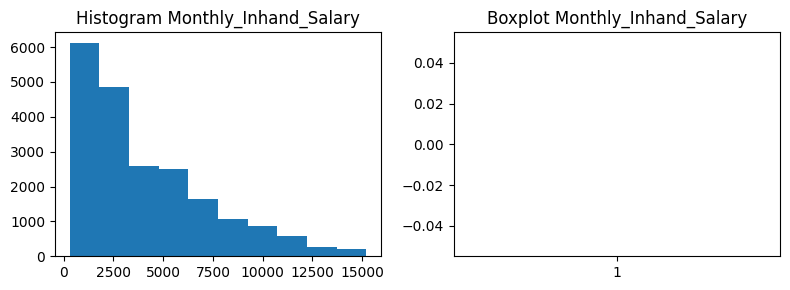

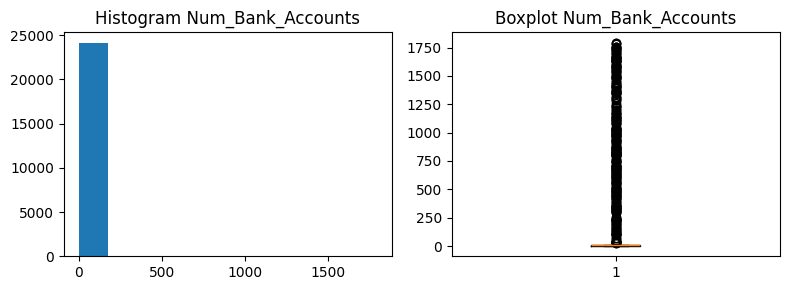

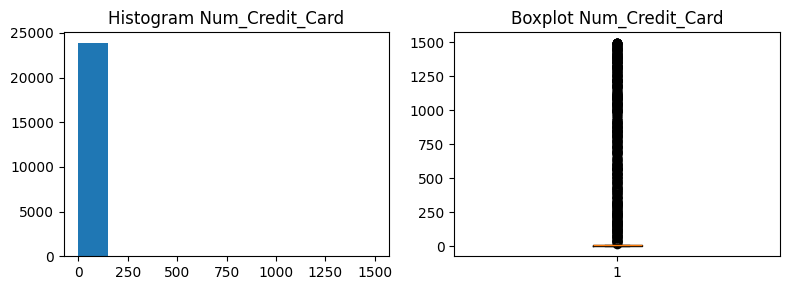

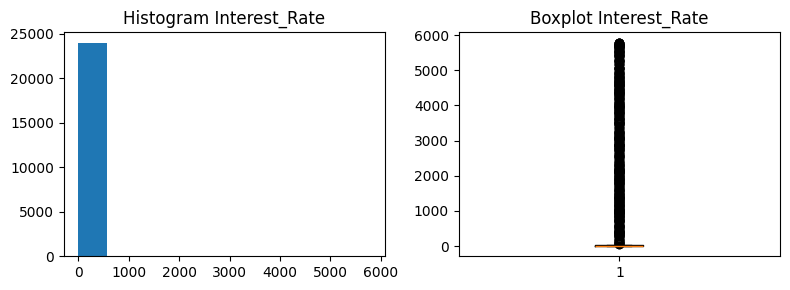

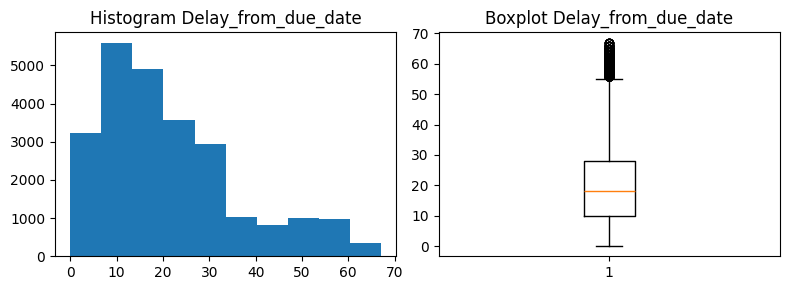

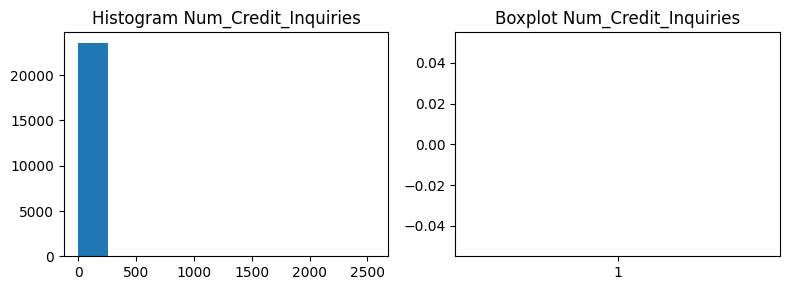

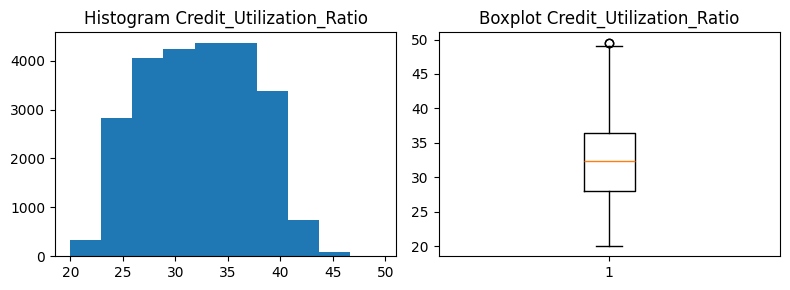

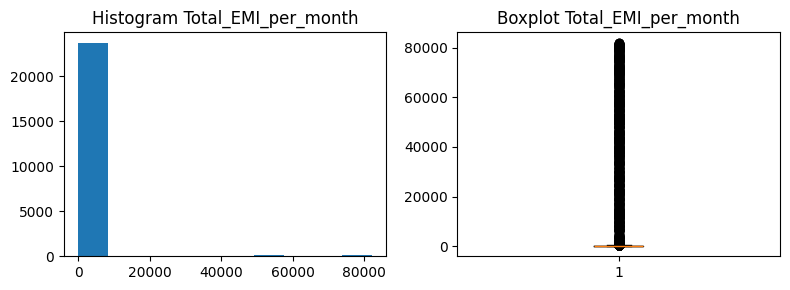

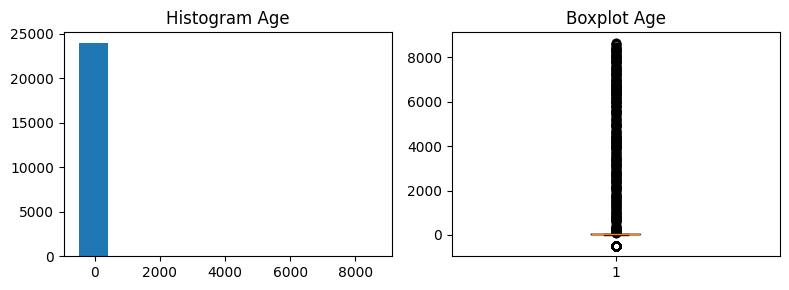

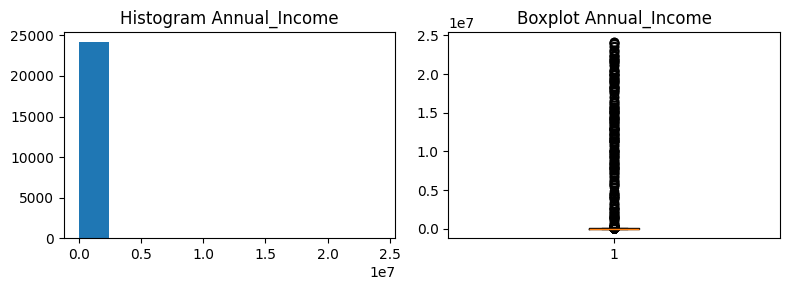

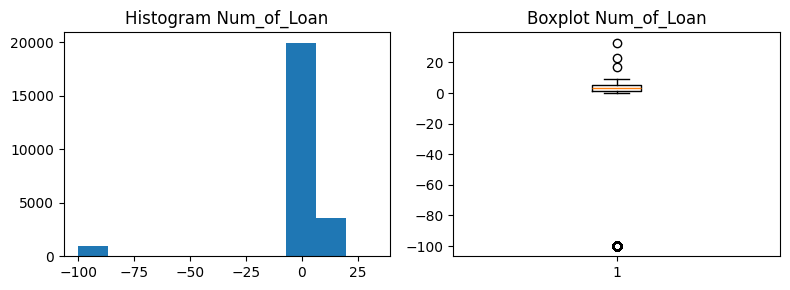

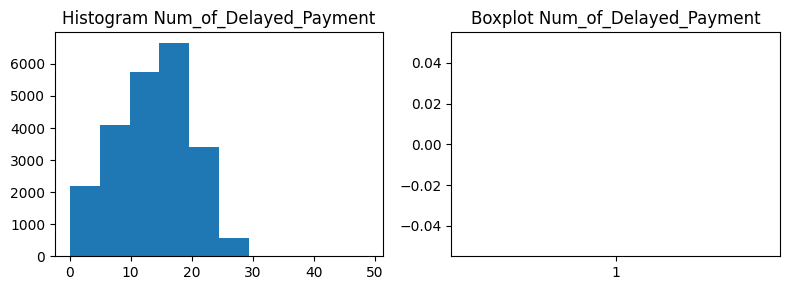

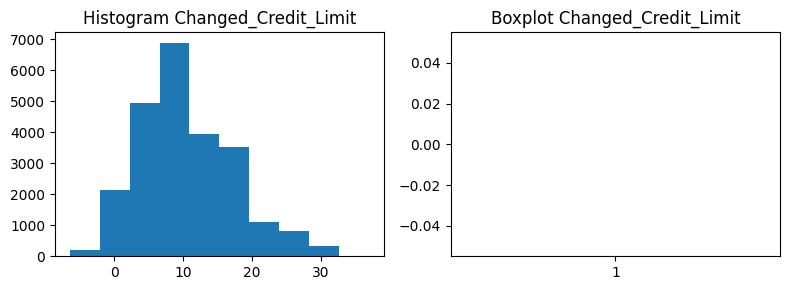

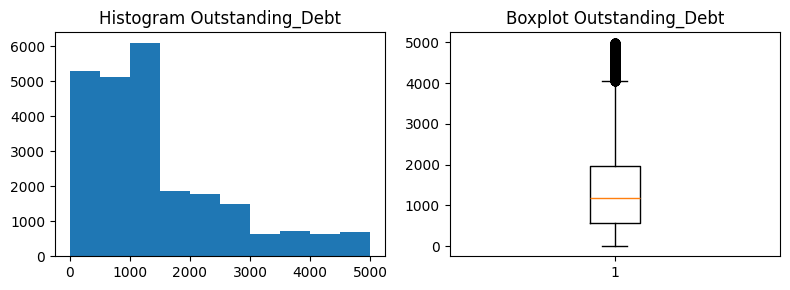

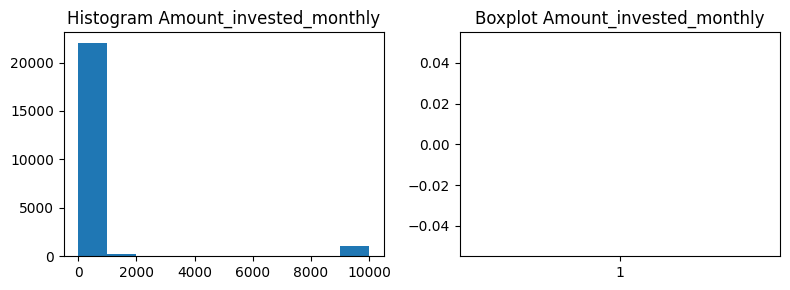

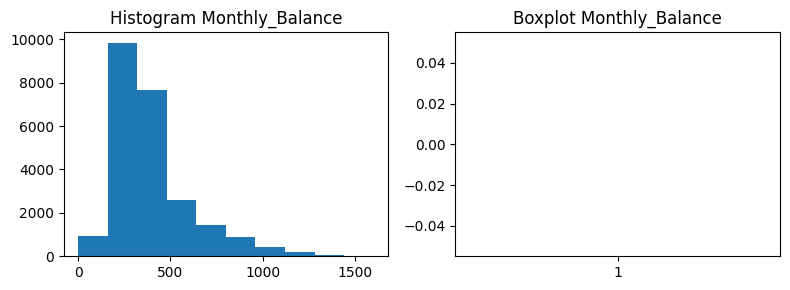

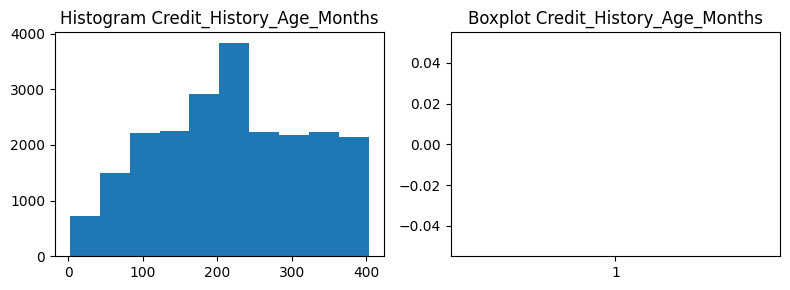

In [35]:
for col in df[num].columns:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].hist(df[col], bins=10)
    axes[0].set_title(f'Histogram {col}')
    axes[1].boxplot(df[col], vert=True)
    axes[1].set_title(f'Boxplot {col}')
    plt.tight_layout()
    plt.show()

### Outlier check

In [36]:
results = []

# Ambil hanya kolom numerik
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    total = df[col].notna().sum()

    low_outliers = (df[col] < lower_bound).sum()
    high_outliers = (df[col] > upper_bound).sum()

    results.append({
        'Feature': col,
        'Low_Outlier_Count': low_outliers,
        'Low_Outlier_%': round(low_outliers / total * 100, 2),
        'High_Outlier_Count': high_outliers,
        'High_Outlier_%': round(high_outliers / total * 100, 2),
        'Total_Outlier_%': round((low_outliers + high_outliers) / total * 100, 2)
    })

outlier_summary = pd.DataFrame(results)

# Urutkan berdasarkan proporsi total outlier terbesar
outlier_summary = outlier_summary.sort_values(
    by='Total_Outlier_%',
    ascending=False
)
outlier_summary

,Feature,Low_Outlier_Count,Low_Outlier_%,High_Outlier_Count,High_Outlier_%,Total_Outlier_%
14,Amount_invested_monthly,0,0.00,2467,10.59,10.59
15,Monthly_Balance,0,0.00,1949,8.09,8.09
13,Total_EMI_per_month,0,0.00,1646,6.75,6.75
11,Outstanding_Debt,0,0.00,1300,5.33,5.33
7,Delay_from_due_date,0,0.00,992,4.07,4.07
6,Num_of_Loan,917,3.76,3,0.01,3.77
1,Annual_Income,0,0.00,693,2.84,2.84
0,Age,207,0.85,469,1.92,2.77
4,Num_Credit_Card,0,0.00,570,2.34,2.34
2,Monthly_Inhand_Salary,0,0.00,437,2.12,2.12


outlier > 1% diimpute, sisanya di drop





In [37]:
mask_all = pd.Series(False, index=df.index)

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)

    if mask.mean() * 100 < 1:
        mask_all |= mask

df = df[~mask_all]

In [38]:
df.shape

(24228, 24)

In [39]:
results = []

# Ambil hanya kolom numerik
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    total = df[col].notna().sum()

    low_outliers = (df[col] < lower_bound).sum()
    high_outliers = (df[col] > upper_bound).sum()

    results.append({
        'Feature': col,
        'Low_Outlier_Count': low_outliers,
        'Low_Outlier_%': round(low_outliers / total * 100, 2),
        'High_Outlier_Count': high_outliers,
        'High_Outlier_%': round(high_outliers / total * 100, 2),
        'Total_Outlier_%': round((low_outliers + high_outliers) / total * 100, 2)
    })

outlier_summary = pd.DataFrame(results)

# Urutkan berdasarkan proporsi total outlier terbesar
outlier_summary = outlier_summary.sort_values(
    by='Total_Outlier_%',
    ascending=False
)
outlier_summary

,Feature,Low_Outlier_Count,Low_Outlier_%,High_Outlier_Count,High_Outlier_%,Total_Outlier_%
14,Amount_invested_monthly,0,0.00,2455,10.61,10.61
15,Monthly_Balance,0,0.00,1925,8.05,8.05
13,Total_EMI_per_month,0,0.00,1635,6.75,6.75
11,Outstanding_Debt,0,0.00,1317,5.44,5.44
7,Delay_from_due_date,0,0.00,976,4.03,4.03
6,Num_of_Loan,914,3.77,3,0.01,3.78
1,Annual_Income,0,0.00,684,2.82,2.82
0,Age,206,0.85,467,1.93,2.78
4,Num_Credit_Card,0,0.00,565,2.33,2.33
2,Monthly_Inhand_Salary,0,0.00,424,2.07,2.07


## Object

In [40]:
obj=['Month','Occupation','Type_of_Loan',
     'Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour']

In [41]:
df[obj].head()

,Month,Occupation,Type_of_Loan,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour
0,June,Doctor,"Credit-Builder Loan, and Mortgage Loan",Standard,Yes,High_spent_Medium_value_payments
1,March,Entrepreneur,"Mortgage Loan, Personal Loan, Payday Loan, Per...",Bad,Yes,High_spent_Small_value_payments
2,February,Accountant,"Student Loan, Home Equity Loan, and Credit-Bui...",_,Yes,High_spent_Medium_value_payments
3,June,_______,"Mortgage Loan, Personal Loan, Home Equity Loan...",Bad,Yes,Low_spent_Medium_value_payments
4,June,Scientist,"Student Loan, Mortgage Loan, and Credit-Builde...",Standard,No,High_spent_Large_value_payments


In [42]:
df[obj].info()

<class 'pandas.core.frame.DataFrame'>
Index: 24228 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Month                  24228 non-null  object
 1   Occupation             24228 non-null  object
 2   Type_of_Loan           21454 non-null  object
 3   Credit_Mix             24228 non-null  object
 4   Payment_of_Min_Amount  24228 non-null  object
 5   Payment_Behaviour      24228 non-null  object
dtypes: object(6)
memory usage: 1.3+ MB


In [43]:
for col in df[obj].columns:
  print(df[col].value_counts())
  print("--------------------------------------")

Month
August      3087
January     3059
June        3055
May         3052
April       3050
July        3022
February    2999
March       2904
Name: count, dtype: int64
--------------------------------------
Occupation
_______          1678
Lawyer           1641
Architect        1564
Scientist        1540
Developer        1539
Mechanic         1530
Engineer         1529
Accountant       1513
Doctor           1507
Teacher          1503
Media_Manager    1503
Entrepreneur     1491
Manager          1452
Journalist       1440
Musician         1418
Writer           1380
Name: count, dtype: int64
--------------------------------------
Type_of_Loan
Not Specified                                                                                                          320
Personal Loan                                                                                                          317
Credit-Builder Loan                                                                                       

variabel type of loan sangat tinggi dalam cardinality, dengan >20% dari total data merupakan unique value



In [44]:
df['Type_of_Loan'] = (
    df['Type_of_Loan']
    .astype(str)
    .str.split(',')
    .str[0]
    .str.strip()
)

In [45]:
print(df['Type_of_Loan'].value_counts())

Type_of_Loan
nan                        2774
Credit-Builder Loan        2535
Payday Loan                2530
Personal Loan              2451
Not Specified              2370
Auto Loan                  2366
Mortgage Loan              2334
Debt Consolidation Loan    2326
Student Loan               2314
Home Equity Loan           2228
Name: count, dtype: int64


In [46]:
df['Spending_Level'] = (df['Payment_Behaviour'].str.extract(r'(Low|High)_spent')[0])

df['Payment_Size'] = (df['Payment_Behaviour'].str.extract(r'(Small|Medium|Large)_value')[0])

df.drop(columns=['Payment_Behaviour'], inplace=True)

In [47]:
obj=['Month','Occupation','Type_of_Loan', 'Spending_Level','Payment_Size',
     'Credit_Mix','Payment_of_Min_Amount']

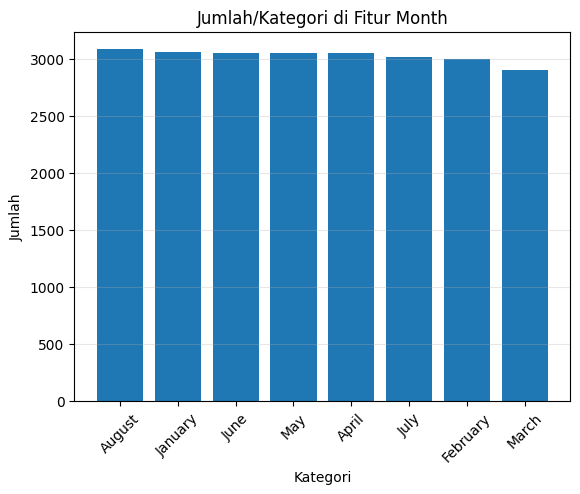

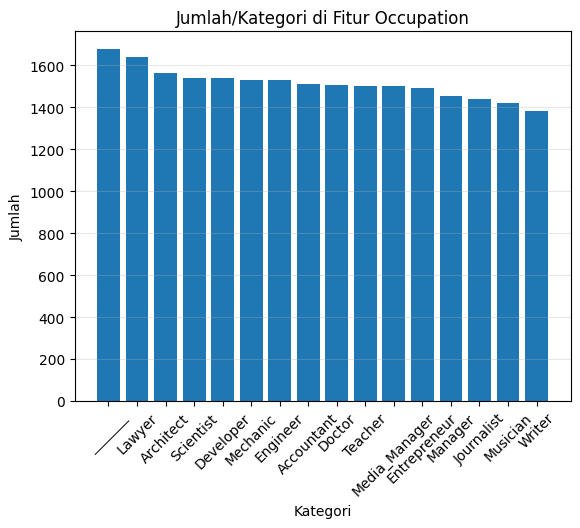

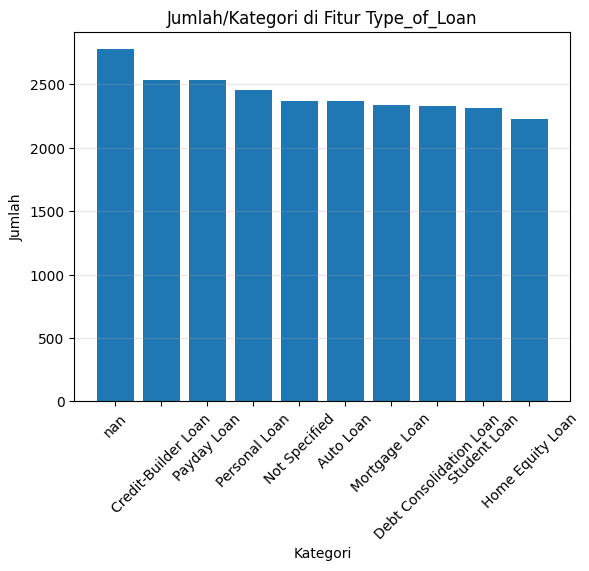

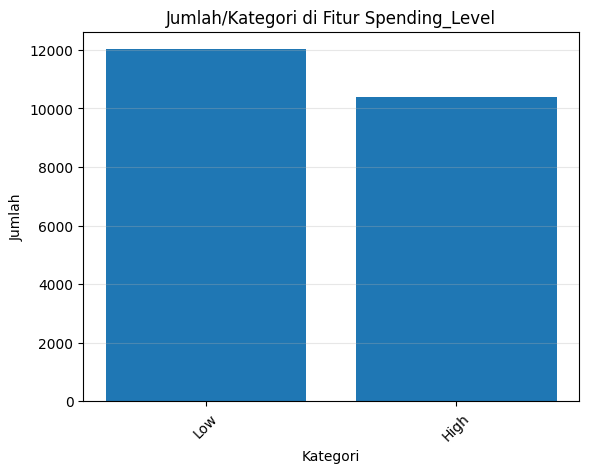

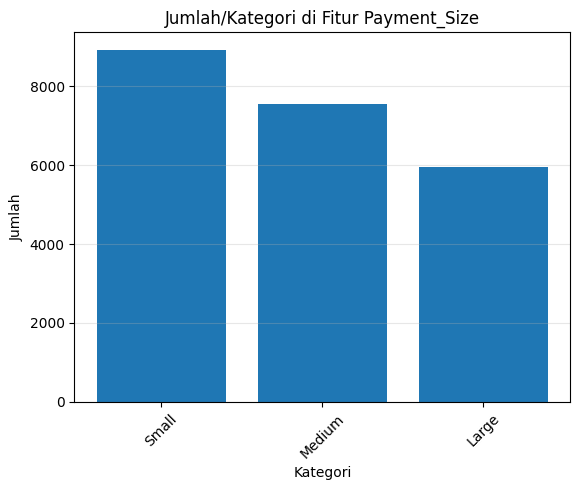

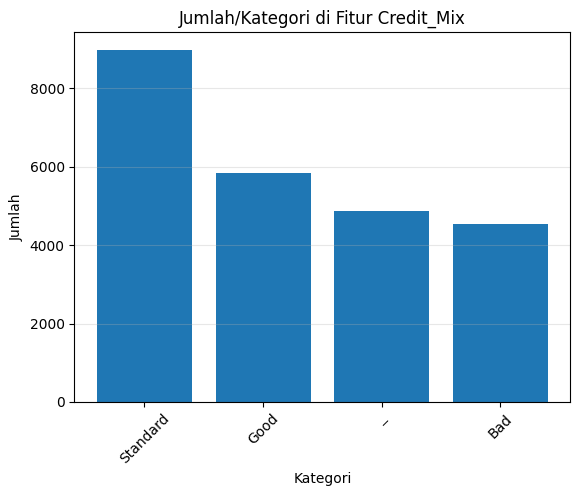

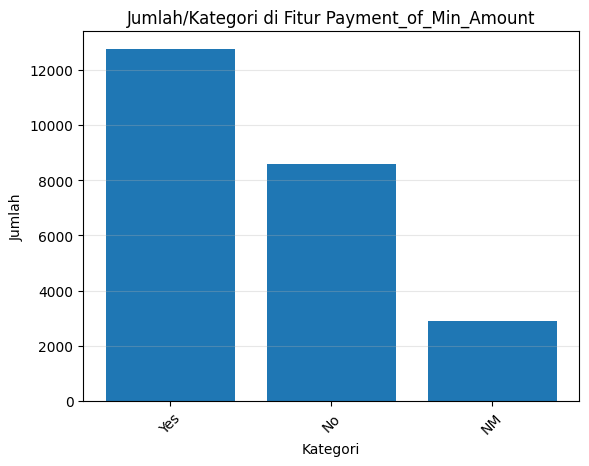

In [48]:
for col in df[obj].columns:

  counts = df[col].value_counts()
  plt.bar(counts.index, counts.values)
  plt.title(f"Jumlah/Kategori di Fitur {col}")
  plt.xlabel("Kategori")
  plt.ylabel("Jumlah")
  plt.grid(axis='y', alpha=0.3)
  plt.xticks(rotation=45)
  plt.show()

terdapat beberapa inconsistencies yang seharusnya NAN

In [ ]:
df = df.replace({
    'nan': np.nan,
    'NaN': np.nan,
    'NAN': np.nan,
    '_': np.nan,
    'Not Specified': np.nan,
    'NM': np.nan,
    '!@9#%8': np.nan,
    '_______': np.nan
})

### Cek Missing Values

In [50]:
null_summary = pd.DataFrame({
    'Column': df[obj].columns,
    'Missing_Count': df[obj].isnull().sum().values,
    'Missing_Percentage': (df[obj].isnull().mean() * 100).values
})

null_summary = null_summary.sort_values(
    by='Missing_Percentage',
    ascending=False
).reset_index(drop=True)

null_summary

,Column,Missing_Count,Missing_Percentage
0,Type_of_Loan,5144,21.231633
1,Credit_Mix,4873,20.113092
2,Payment_of_Min_Amount,2881,11.891200
3,Payment_Size,1828,7.544989
4,Spending_Level,1828,7.544989
5,Occupation,1678,6.925871
6,Month,0,0.000000


missing values akan diimpute ke frekuensi tertinggi

## Exploratory Data Analysis

### Feature Realationship

In [51]:
col=['Month', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', 'Credit_History_Age_Months','Spending_Level','Payment_Size']

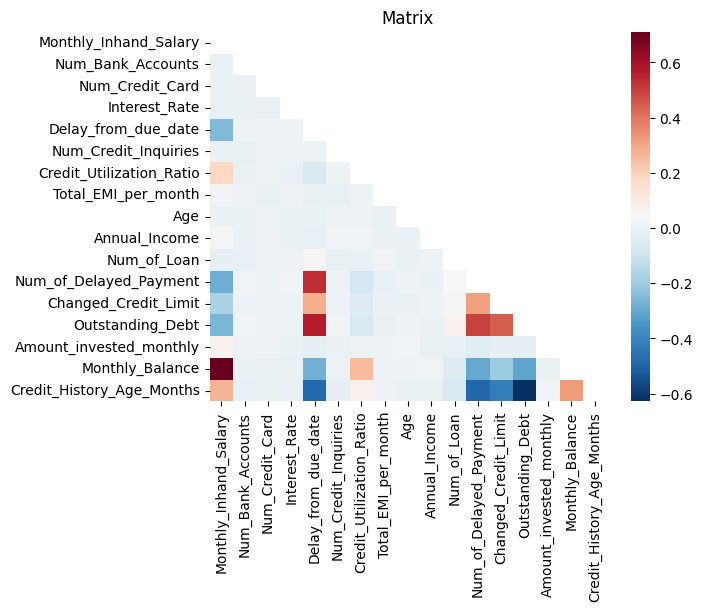

In [ ]:
corr = df[num].corr()
corrl = corr.loc[corr.index, corr.index]
mask1=np.triu(np.ones_like(corrl, dtype=bool))
sns.heatmap(corr.loc[corr.index, corr.index],cmap='RdBu_r',mask=mask1, annot=True)
plt.title("Matrix")
plt.show()

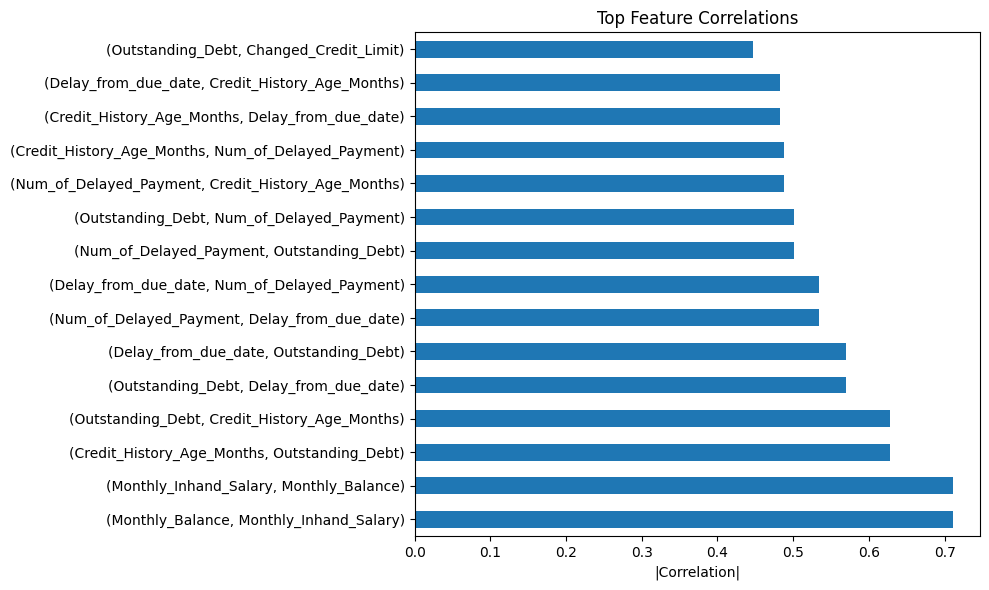

In [ ]:
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1]
top_pairs = corr_pairs.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_pairs.plot(kind='barh')
plt.title('Top Feature Correlations')
plt.xlabel('|Correlation|')
plt.tight_layout()
plt.show()

In [55]:
df_corr = df.copy()

mapping = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

df_corr['Credit_Score'] = df_corr['Credit_Score'].map(mapping)

In [56]:
import matplotlib.pyplot as plt

num_df = df_corr.select_dtypes(include=np.number)

target_corr = num_df.corr()['Credit_Score'].drop('Credit_Score')

target_corr = target_corr.sort_values()

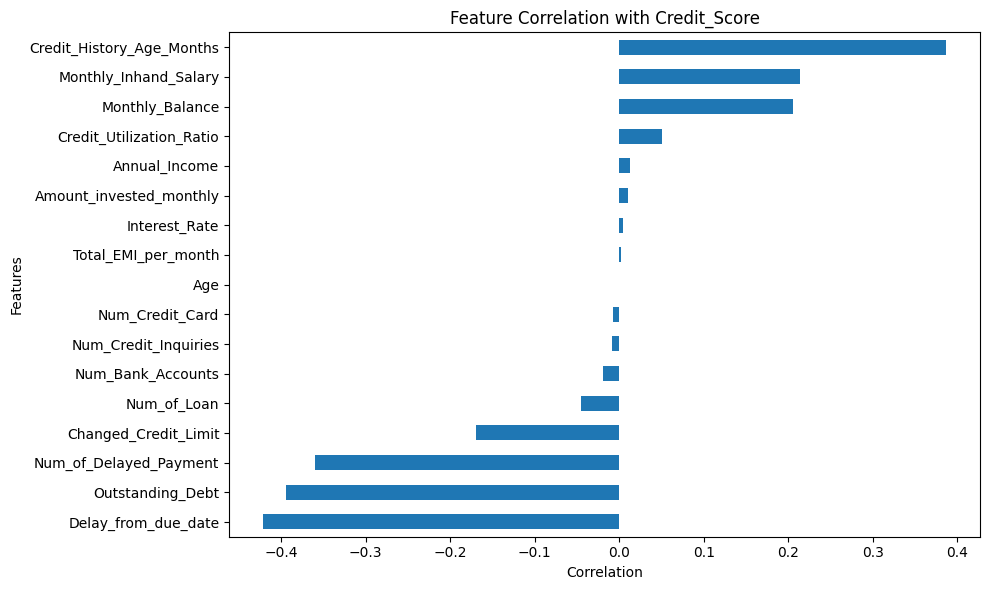

In [57]:
plt.figure(figsize=(10,6))

target_corr.plot(kind='barh')

plt.title('Feature Correlation with Credit_Score')
plt.xlabel('Correlation')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

### Object relationship

In [58]:
def stacked_table(col):
    return pd.crosstab(df[col], df['Credit_Score'], normalize='index') * 100

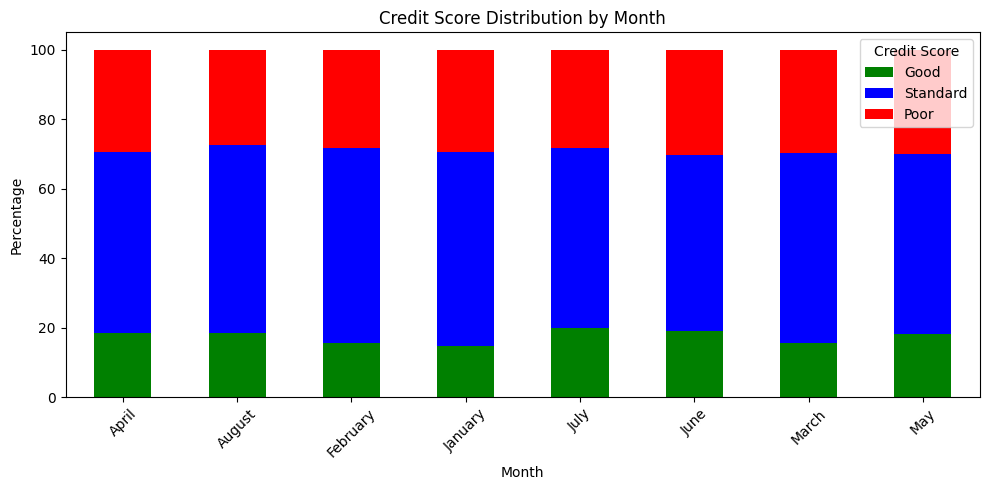

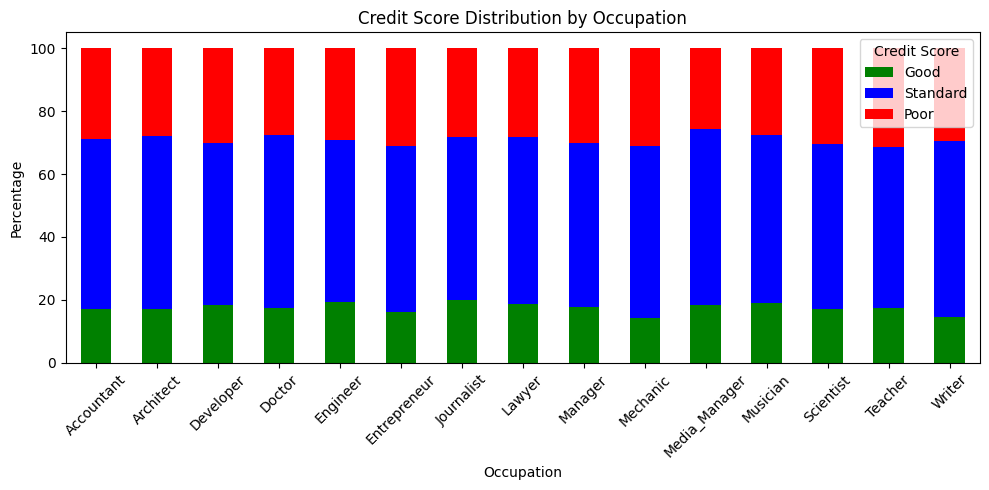

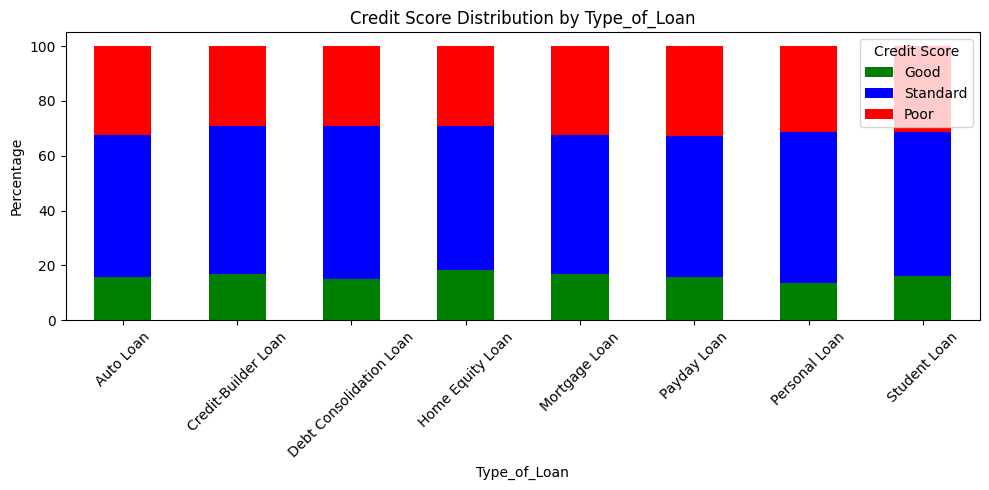

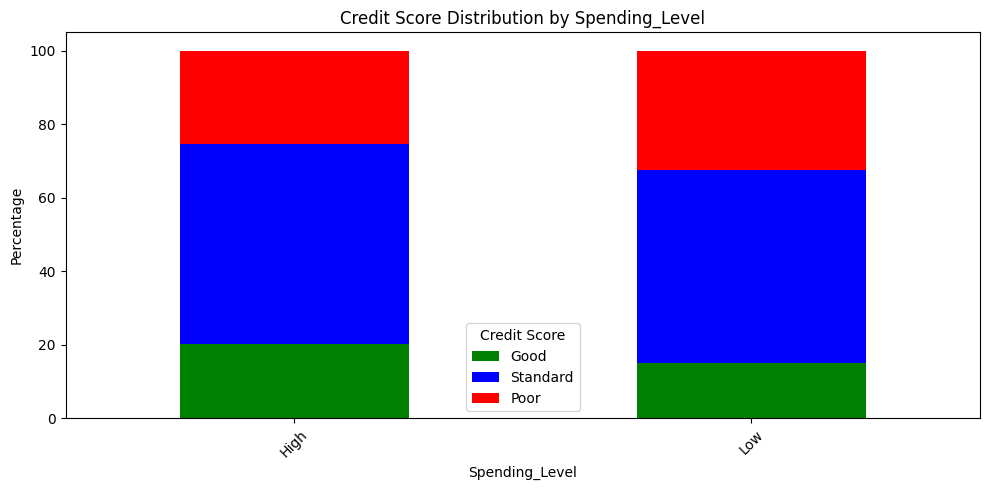

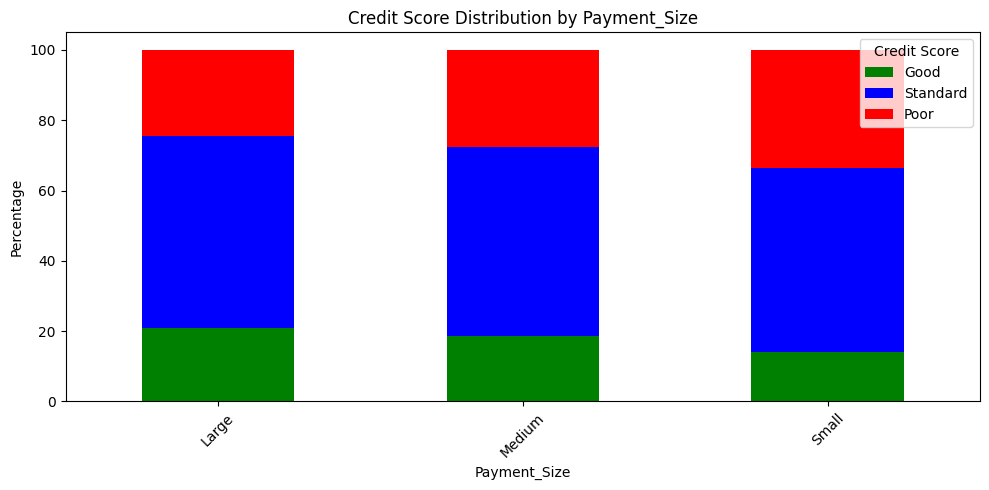

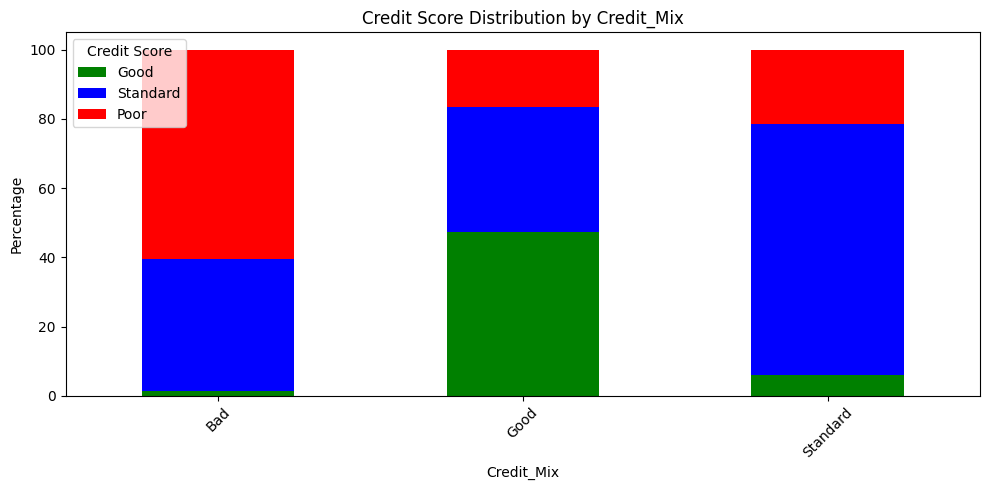

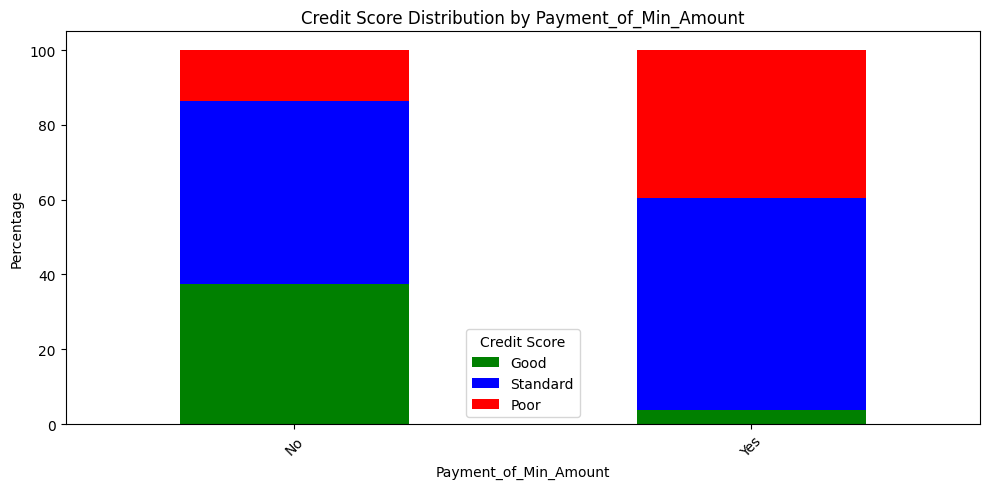

In [59]:
order = ['Good', 'Standard', 'Poor']

colors = {
    'Good': 'green',
    'Standard': 'blue',
    'Poor': 'red'
}

for col in obj:

    table = stacked_table(col)

    # enforce column order
    table = table.reindex(columns=order)

    ax = table.plot(
        kind='bar',
        stacked=True,
        figsize=(10,5),
        color=[colors[c] for c in order]
    )

    plt.title(f'Credit Score Distribution by {col}')
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.legend(title='Credit Score')
    plt.tight_layout()
    plt.show()

In [60]:
df

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,Credit_History_Age_Months,Spending_Level,Payment_Size
0,June,32,Doctor,56125.50,4875.125000,8,3,18,2,Credit-Builder Loan,...,370.22,32.014182,Yes,81.822857,182.065510,473.624133,Standard,346.0,High,Medium
1,March,39,Entrepreneur,62148.00,NaN,9,7,24,5,Mortgage Loan,...,2373.61,33.951720,Yes,258.848861,195.372215,300.678924,Poor,198.0,High,Small
2,February,45,Accountant,88380.16,7471.013333,7,7,19,3,Student Loan,...,124.29,41.016763,Yes,129.723699,180.798742,686.578893,Standard,NaN,High,Medium
3,June,32,NaN,7821.24,468.770000,8,10,29,6,Mortgage Loan,...,2924.76,34.203026,Yes,19.727923,39.937703,267.211374,Standard,122.0,Low,Medium
4,June,18,Scientist,107871.90,NaN,3,4,8,3,Student Loan,...,1005.83,27.237916,No,227.241789,73.485708,820.905003,Standard,392.0,High,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,July,32,Accountant,58892.86,5106.738333,3,4,17,3,Debt Consolidation Loan,...,666.00,29.716761,Yes,118.348232,213.831224,438.494378,Standard,399.0,High,Small
24996,May,45,NaN,75042.72,6484.560000,6,3,13,2,Auto Loan,...,417.62,42.662754,Yes,105.684175,80.531141,702.240684,Standard,211.0,High,Large
24997,May,37,Journalist,25530.33,2137.527500,3,4,19,0,NaN,...,761.18,35.252857,NaN,0.000000,64.221918,429.530832,Standard,381.0,NaN,NaN
24998,July,21,Scientist,34458.06,3142.505000,9,10,29,5,Auto Loan,...,4404.79,37.234923,NaN,119.622458,10000.000000,332.425023,Standard,167.0,High,Small


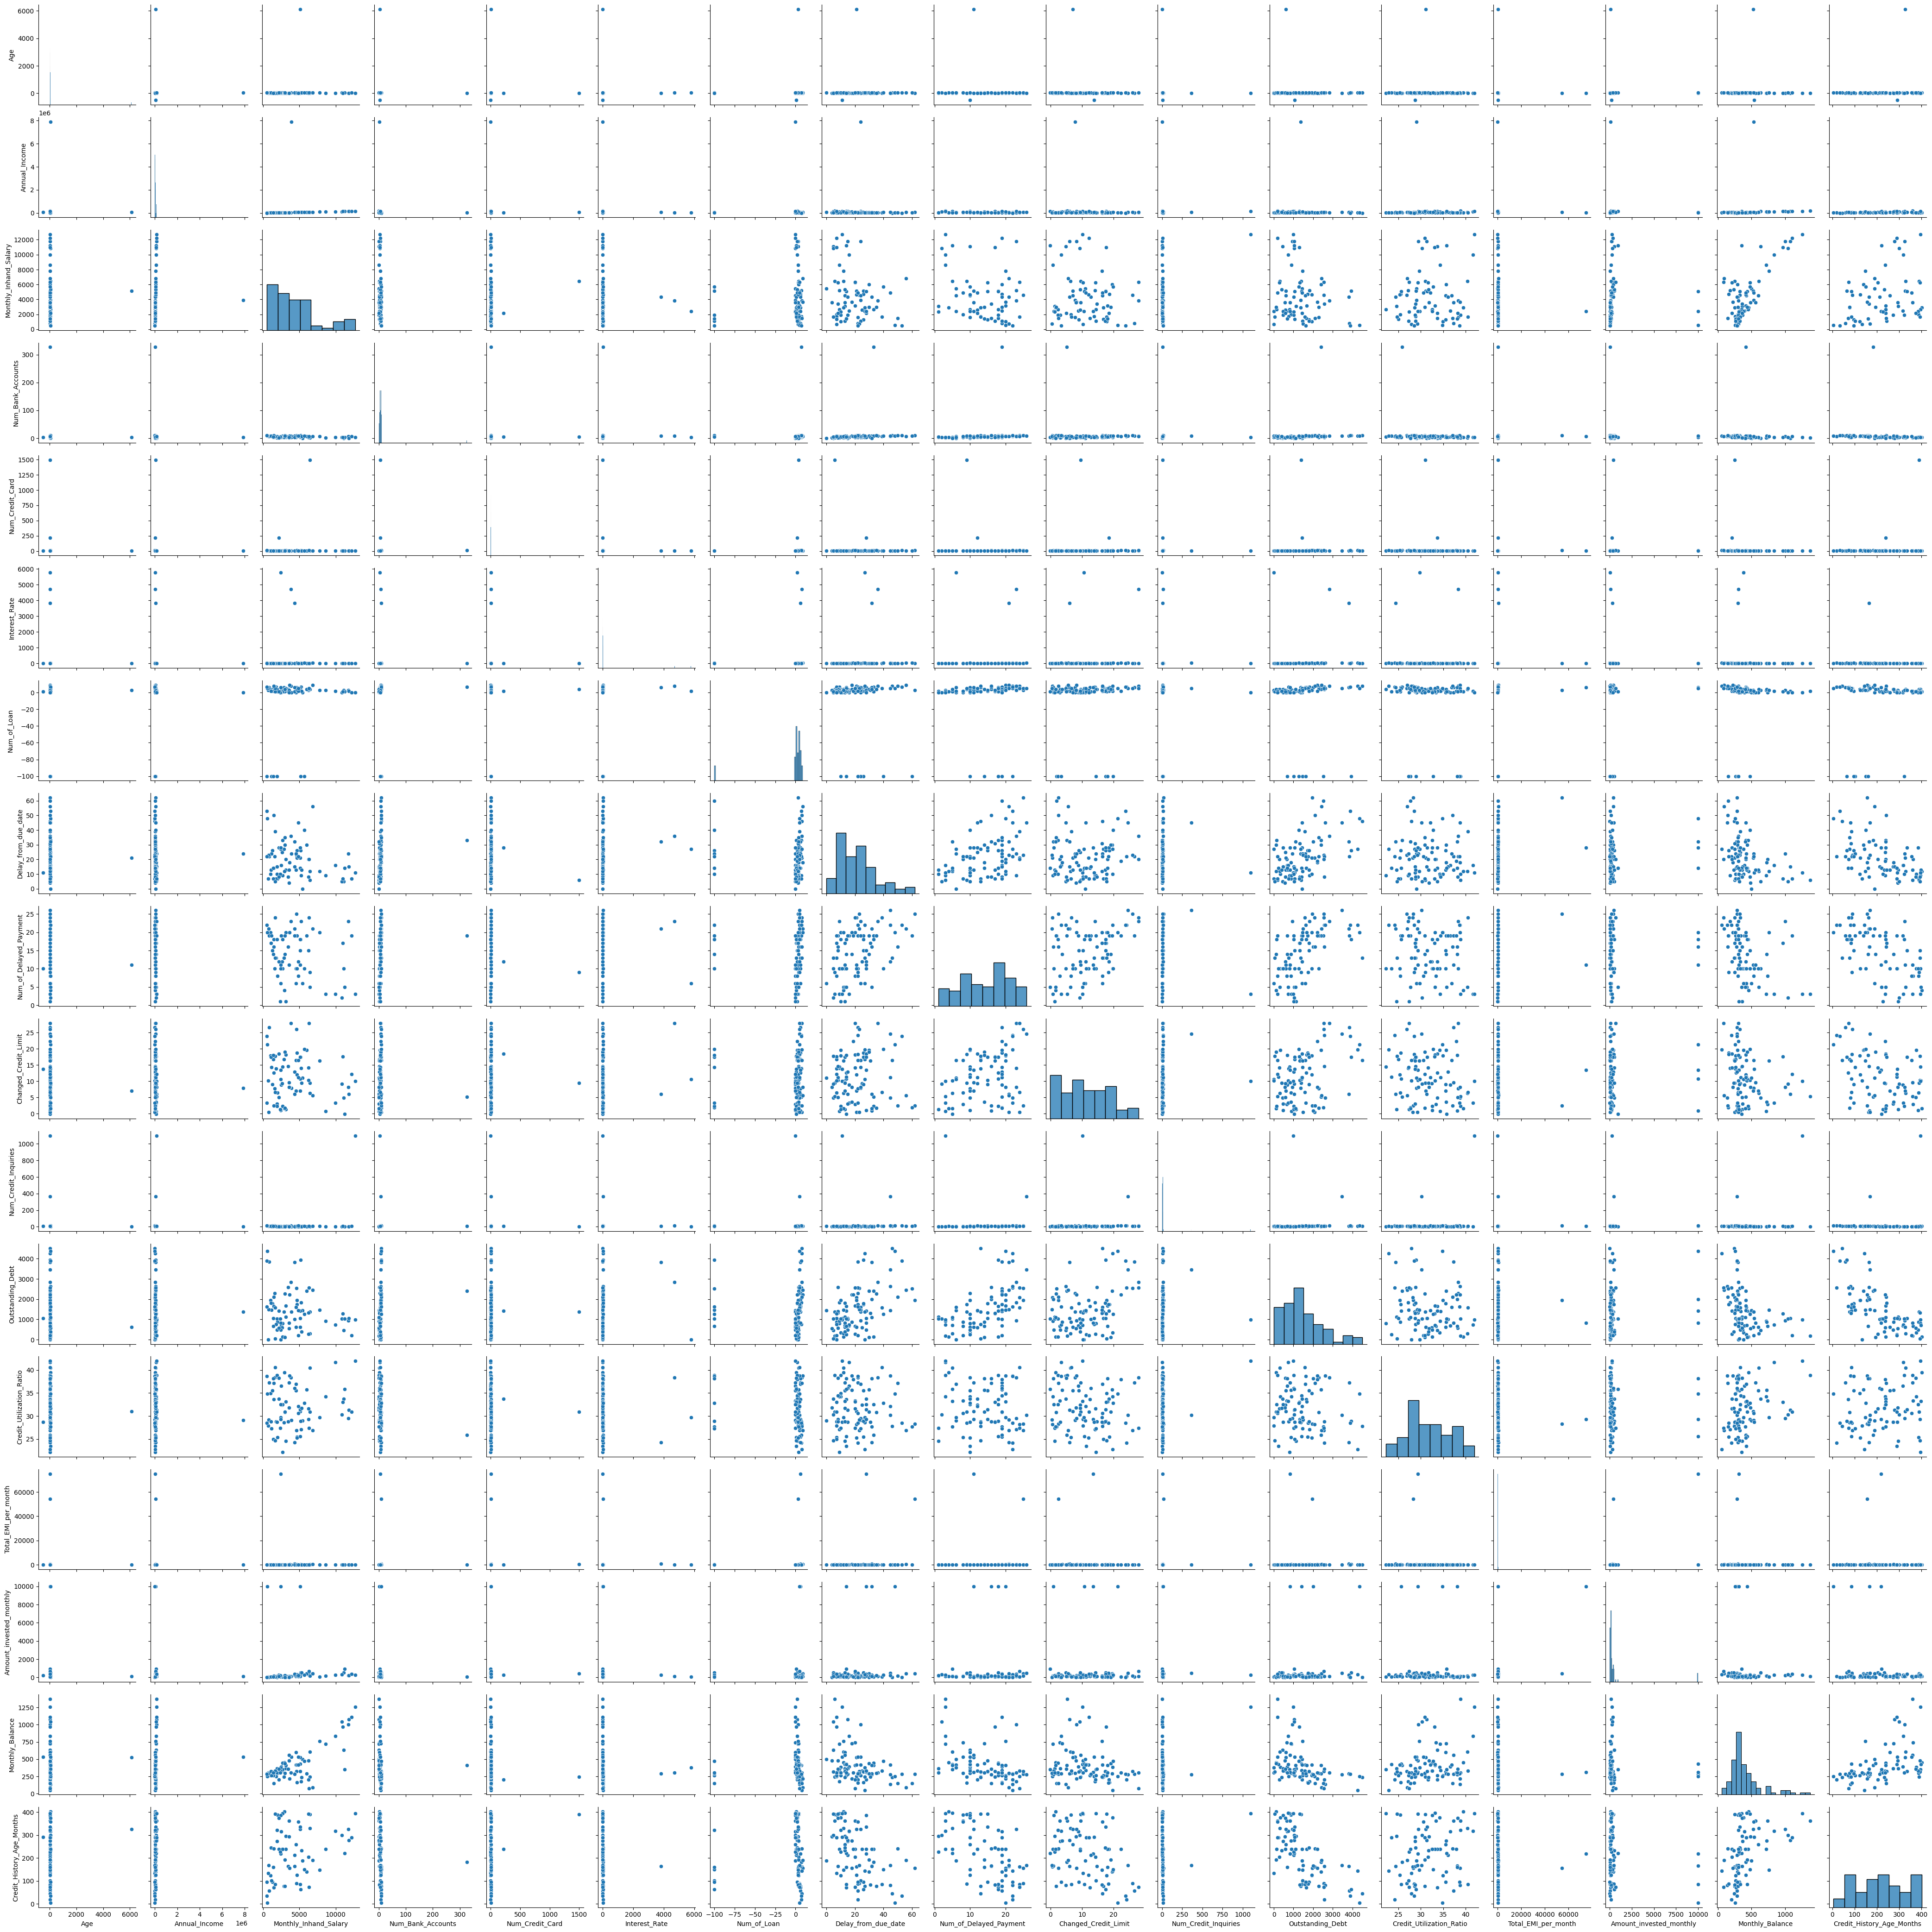

In [61]:
sns.pairplot(df.sample(100))
plt.show()

In [62]:
missing = df.isnull().sum()

print(missing[missing > 0])

Occupation                   1678
Monthly_Inhand_Salary        3714
Type_of_Loan                 5144
Num_of_Delayed_Payment       1719
Changed_Credit_Limit          511
Num_Credit_Inquiries          475
Credit_Mix                   4873
Payment_of_Min_Amount        2881
Amount_invested_monthly      1094
Monthly_Balance               306
Credit_History_Age_Months    2174
Spending_Level               1828
Payment_Size                 1828
dtype: int64


In [63]:
df.shape

(24228, 25)

## Split

In [64]:
x = df.drop(columns = ['Credit_Score'])

y=df['Credit_Score']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify=y)

In [65]:
x_train

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Spending_Level,Payment_Size
948,February,29,Accountant,80918.14,6444.178333,2,5,8,4,Payday Loan,...,Good,216.05,31.739678,No,192.759787,109.311755,582.346291,374.0,High,Large
19611,February,47,Lawyer,17577.76,NaN,3,5,19,2,Debt Consolidation Loan,...,Standard,1447.93,36.529238,Yes,29.295467,139.063450,277.922417,382.0,Low,Large
6186,June,32,Entrepreneur,51162.84,4249.570000,7,10,34,5,Mortgage Loan,...,Bad,1921.03,25.952486,Yes,178.783424,138.818071,357.355506,126.0,High,Medium
841,March,42,NaN,21336.90,1656.075000,3,5,6,1,Debt Consolidation Loan,...,Standard,1338.82,38.544114,Yes,11.230332,100.666587,313.710581,126.0,High,Small
16596,July,35,Lawyer,80661.32,6551.776667,5,4,30,4,Debt Consolidation Loan,...,Standard,1482.15,25.740488,Yes,135.562474,335.046899,464.568294,93.0,Low,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16860,July,21,Developer,22500.52,1770.043333,5,3,19,5,Payday Loan,...,Standard,864.70,23.521787,Yes,65.021026,66.557578,295.425730,153.0,High,Medium
4813,January,31,Architect,38364.82,2904.068333,9,6,32,4,NaN,...,Bad,1973.63,37.664553,NaN,74.850372,74.792519,390.763943,NaN,High,Medium
16618,June,25,Engineer,36943.98,3369.665000,7,9,34,8,Home Equity Loan,...,Bad,4735.18,29.042791,Yes,172.858787,301.133785,152.973928,171.0,Low,Small
10832,August,23,Writer,16674.26,1104.521667,6,6,6,4,Personal Loan,...,Standard,2187.49,26.234789,Yes,29.620106,96.660069,264.171991,218.0,Low,Medium


# Imputing

## Impute Missing Values

### Numeric

In [66]:
from sklearn.impute import SimpleImputer

# create imputer (median strategy)
imputer = SimpleImputer(strategy='median')

# fit only on training data
x_train[num] = imputer.fit_transform(x_train[num])

# transform test data
x_test[num] = imputer.transform(x_test[num])

### Object

In [67]:
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy='most_frequent')

# fit on train only
x_train[obj] = cat_imputer.fit_transform(x_train[obj])

# transform test
x_test[obj] = cat_imputer.transform(x_test[obj])

In [68]:
x_train = pd.DataFrame(x_train, columns=x_train.columns, index=x_train.index)
x_test = pd.DataFrame(x_test, columns=x_test.columns, index=x_test.index)

## Impute Outlier

In [69]:
x_train['Num_Bank_Accounts'] = x_train['Num_Bank_Accounts'].clip(lower=0, upper=100)
x_train['Num_Credit_Card'] = x_train['Num_Credit_Card'].clip(lower=0, upper=100)
x_train['Num_Credit_Inquiries'] = x_train['Num_Credit_Inquiries'].clip(lower=0, upper=1000)
x_train['Interest_Rate'] = x_train['Interest_Rate'].clip(lower=0, upper=100)
x_train['Delay_from_due_date'] = x_train['Delay_from_due_date'].clip(lower=0)
x_train['Age'] = x_train['Age'].clip(lower=18, upper=100)
x_train['Num_of_Loan'] = x_train['Num_of_Loan'].clip(lower=0)

x_test['Num_Bank_Accounts'] = x_test['Num_Bank_Accounts'].clip(lower=0, upper=100)
x_test['Num_Credit_Card'] = x_test['Num_Credit_Card'].clip(lower=0, upper=100)
x_test['Num_Credit_Inquiries'] = x_test['Num_Credit_Inquiries'].clip(lower=0, upper=1000)
x_test['Interest_Rate'] = x_test['Interest_Rate'].clip(lower=0, upper=100)
x_test['Delay_from_due_date'] = x_test['Delay_from_due_date'].clip(lower=0)
x_test['Age'] = x_test['Age'].clip(lower=18, upper=100)
x_test['Num_of_Loan'] = x_test['Num_of_Loan'].clip(lower=0)

In [ ]:
for col in num:

    Q1 = x_train[col].quantile(0.25)
    Q3 = x_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    x_train[col] = x_train[col].clip(lower=lower, upper=upper)

In [71]:
for col in num:

    Q1 = x_test[col].quantile(0.25)
    Q3 = x_test[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    x_test[col] = x_test[col].clip(lower=lower, upper=upper)

In [72]:
x_train.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months
count,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000
mean,34.108658,50753.013726,3910.294389,5.498091,5.666649,14.986276,3.383603,20.998091,13.435249,10.286470,5.975751,1390.405676,32.249292,106.722049,188.220004,386.485023,221.621040
std,11.508085,38266.629954,2716.934033,2.748091,2.216754,9.263750,2.483514,14.315785,5.982622,6.545971,4.088797,1073.928451,5.105533,103.544309,152.043351,170.029153,95.457991
min,18.000000,7005.930000,303.645417,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-6.440000,0.000000,0.230000,20.000000,0.000000,0.000000,0.599640,3.000000
25%,25.000000,19536.450000,1791.294479,4.000000,4.000000,8.000000,1.000000,10.000000,9.000000,5.480000,3.000000,566.747500,28.048733,29.865025,75.789824,272.095133,154.000000
50%,33.000000,37194.580000,3077.729167,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.350000,6.000000,1159.485000,32.303866,68.348799,133.116031,338.109962,220.000000
75%,42.000000,72195.240000,5301.346875,8.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.617500,9.000000,1933.750000,36.440894,160.188112,251.388404,464.601199,293.000000
max,67.500000,151183.425000,10566.425469,14.000000,11.500000,38.000000,11.000000,55.000000,28.000000,28.323750,18.000000,3984.253750,49.029134,355.672742,514.786273,753.360297,404.000000


# Encoding

In [73]:
for col in df[obj].columns:
  print(df[col].value_counts())
  print("--------------------------------------")

Month
August      3087
January     3059
June        3055
May         3052
April       3050
July        3022
February    2999
March       2904
Name: count, dtype: int64
--------------------------------------
Occupation
Lawyer           1641
Architect        1564
Scientist        1540
Developer        1539
Mechanic         1530
Engineer         1529
Accountant       1513
Doctor           1507
Teacher          1503
Media_Manager    1503
Entrepreneur     1491
Manager          1452
Journalist       1440
Musician         1418
Writer           1380
Name: count, dtype: int64
--------------------------------------
Type_of_Loan
Credit-Builder Loan        2535
Payday Loan                2530
Personal Loan              2451
Auto Loan                  2366
Mortgage Loan              2334
Debt Consolidation Loan    2326
Student Loan               2314
Home Equity Loan           2228
Name: count, dtype: int64
--------------------------------------
Spending_Level
Low     12017
High    10383
Name: coun

Ordinal Encoding
- Month
- Credit Mix
- Payment behaviour

Binary encoding
- Payment min amount

OHE
- occupation
- Type of loan

In [74]:
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8
}

x_train['Month'] = x_train['Month'].map(month_map)
x_test['Month'] = x_test['Month'].map(month_map)

In [75]:
credit_mix_map = {
    'Bad': 0,
    'Standard': 1,
    'Good': 2
}

x_train['Credit_Mix'] = x_train['Credit_Mix'].map(credit_mix_map)
x_test['Credit_Mix'] = x_test['Credit_Mix'].map(credit_mix_map)

In [76]:
x_train['Spending_Level'] = x_train['Spending_Level'].map({'Low': 0, 'High': 1})
x_test['Spending_Level'] = x_test['Spending_Level'].map({'Low': 0, 'High': 1})

x_train['Payment_Size'] = x_train['Payment_Size'].map({'Small': 0, 'Medium': 1, 'Large': 2})
x_test['Payment_Size'] = x_test['Payment_Size'].map({'Small': 0, 'Medium': 1, 'Large': 2})

In [77]:
credit_score_map = {
    'Good':2,
    'Standard':1,
    'Poor':0
}

y_train = y_train.map(credit_score_map)
y_test = y_test.map(credit_score_map)

In [78]:
x_train['Payment_of_Min_Amount']

,Payment_of_Min_Amount
948,No
19611,Yes
6186,Yes
841,Yes
16596,Yes
...,...
16860,Yes
4813,Yes
16618,Yes
10832,Yes


In [79]:
payment_map = {
    'No': 0,
    'Yes': 1
}
x_train['Payment_of_Min_Amount'] = x_train['Payment_of_Min_Amount'].map(payment_map)
x_test['Payment_of_Min_Amount'] = x_test['Payment_of_Min_Amount'].map(payment_map)

In [80]:
x_train['Payment_of_Min_Amount']

,Payment_of_Min_Amount
948,0
19611,1
6186,1
841,1
16596,1
...,...
16860,1
4813,1
16618,1
10832,1


In [81]:
from sklearn.preprocessing import OneHotEncoder

ohe = ['Occupation', 'Type_of_Loan']

encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# Encode
train_encoded = encoder.fit_transform(x_train[ohe])
test_encoded = encoder.transform(x_test[ohe])

# Get new column names
encoded_cols = encoder.get_feature_names_out(ohe)

# Convert to DataFrame
train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoded_cols,
    index=x_train.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=encoded_cols,
    index=x_test.index
)

# Remove original columns and add encoded columns
x_train = pd.concat(
    [x_train.drop(columns=ohe), train_encoded],
    axis=1
)

x_test = pd.concat(
    [x_test.drop(columns=ohe), test_encoded],
    axis=1
)

# Modelling - Classification

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# initialize models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
# train

dt.fit(x_train, y_train)
rf.fit(x_train, y_train)

# predict
models = {
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(x_test)

    print("\n" + "="*50)
    print(f"{name}")

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # Classification report (precision, recall, f1 per class)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix (optional but very useful)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Decision Tree
Accuracy: 0.6368

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.60      0.60      1413
           1       0.69      0.69      0.69      2586
           2       0.53      0.53      0.53       847

    accuracy                           0.64      4846
   macro avg       0.61      0.61      0.61      4846
weighted avg       0.64      0.64      0.64      4846

Confusion Matrix:
[[ 851  484   78]
 [ 474 1788  324]
 [  77  323  447]]

Random Forest
Accuracy: 0.7336

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.71      0.72      1413
           1       0.75      0.79      0.77      2586
           2       0.66      0.61      0.63       847

    accuracy                           0.73      4846
   macro avg       0.72      0.70      0.71      4846
weighted avg       0.73      0.73      0.73      4846

Confusion Matrix:
[[ 999  355   59]
 [ 339 2037  210]

## Cek overfitting

In [83]:
print("Decision Tree Train:", dt.score(x_train, y_train))
print("Decision Tree Test:", dt.score(x_test, y_test))

print("Random Forest Train:", rf.score(x_train, y_train))
print("Random Forest Test:", rf.score(x_test, y_test))

Decision Tree Train: 1.0
Decision Tree Test: 0.6368138671068923
Random Forest Train: 1.0
Random Forest Test: 0.7335947172926125


decision tree dan random forest sangat overfit

## Hyperparameter Tuning

In [84]:
x_train.shape

(19382, 43)

In [94]:
class_weights = {
    2: 0.8,
    1: 2.0,
    0: 2.8
}

In [87]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy={0: 25000, 1: 14000, 2: 18000})

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)

In [88]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


Decision Tree
Accuracy: 0.6331
              precision    recall  f1-score   support

           0       0.55      0.80      0.65      1413
           1       0.74      0.61      0.67      2586
           2       0.56      0.42      0.48       847

    accuracy                           0.63      4846
   macro avg       0.61      0.61      0.60      4846
weighted avg       0.65      0.63      0.63      4846



<Figure size 600x500 with 0 Axes>

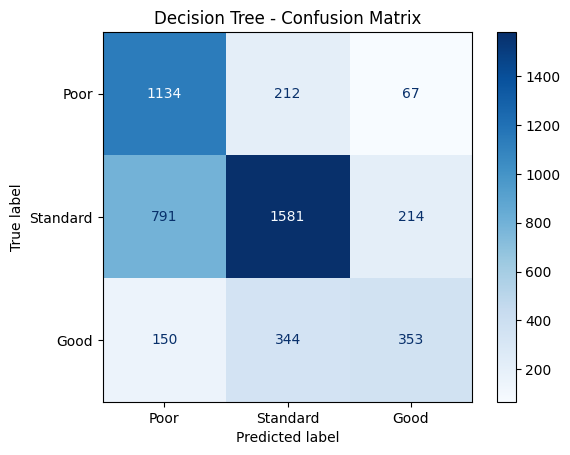


Random Forest
Accuracy: 0.6671
              precision    recall  f1-score   support

           0       0.58      0.85      0.69      1413
           1       0.78      0.62      0.69      2586
           2       0.59      0.52      0.56       847

    accuracy                           0.67      4846
   macro avg       0.65      0.66      0.64      4846
weighted avg       0.69      0.67      0.67      4846



<Figure size 600x500 with 0 Axes>

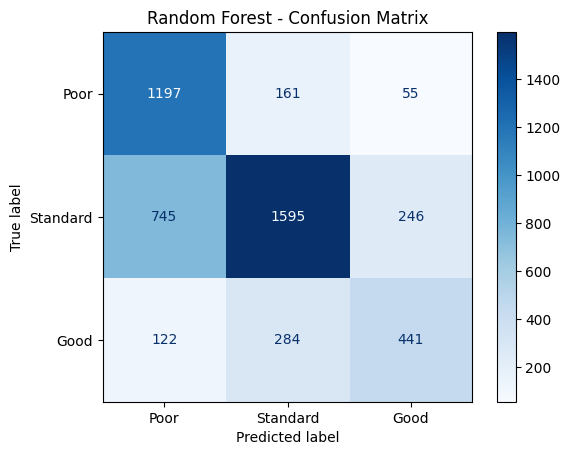


XGBoost
Accuracy: 0.6723
              precision    recall  f1-score   support

           0       0.62      0.82      0.71      1413
           1       0.85      0.55      0.67      2586
           2       0.51      0.81      0.63       847

    accuracy                           0.67      4846
   macro avg       0.66      0.72      0.67      4846
weighted avg       0.73      0.67      0.67      4846



<Figure size 600x500 with 0 Axes>

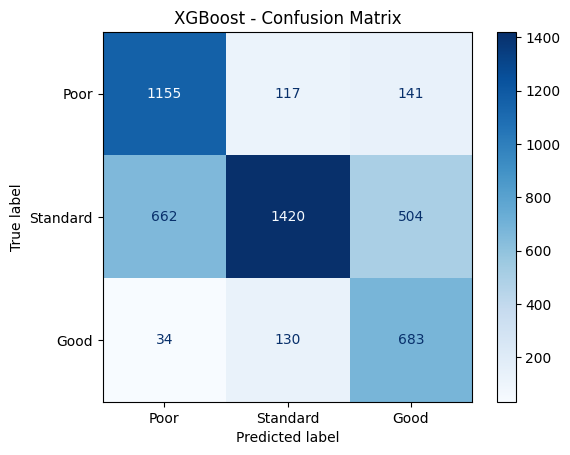

In [95]:
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    class_weight=class_weights
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=4,
    class_weight=class_weights,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=1,
    max_depth=10,
    learning_rate=0.01,
    subsample=0.5,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    class_weights=class_weights
)

# Train
dt.fit(x_train_smote, y_train_smote)
rf.fit(x_train_smote, y_train_smote)
xgb.fit(x_train_smote, y_train_smote)

# Evaluate
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():

    y_pred = model.predict(x_test)

    print("\n" + "=" * 50)
    print(name)

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    print(classification_report(y_test, y_pred))

    # =====================================
    # MULTICLASS CONFUSION MATRIX
    # =====================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Poor", "Standard", "Good"]
    )
    disp.plot(cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


In [ ]:
print("Decision Tree Train:", dt.score(x_train_smote, y_train_smote))
print("Decision Tree Test:", dt.score(x_test, y_test))

print("Random Forest Train:", rf.score(x_train_smote, y_train_smote))
print("Random Forest Test:", rf.score(x_test, y_test))

print("XGB Train:", xgb.score(x_train_smote, y_train_smote))
print("XGB Test:", xgb.score(x_test, y_test))